Successfully read 6302 rows from nouvelle_sesame_fe.dat.

Generating Plots...


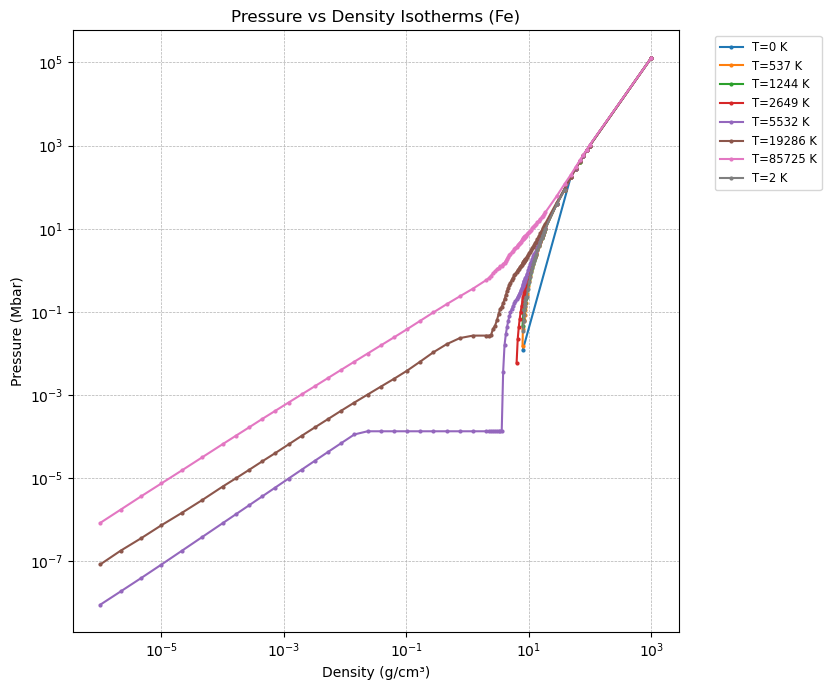

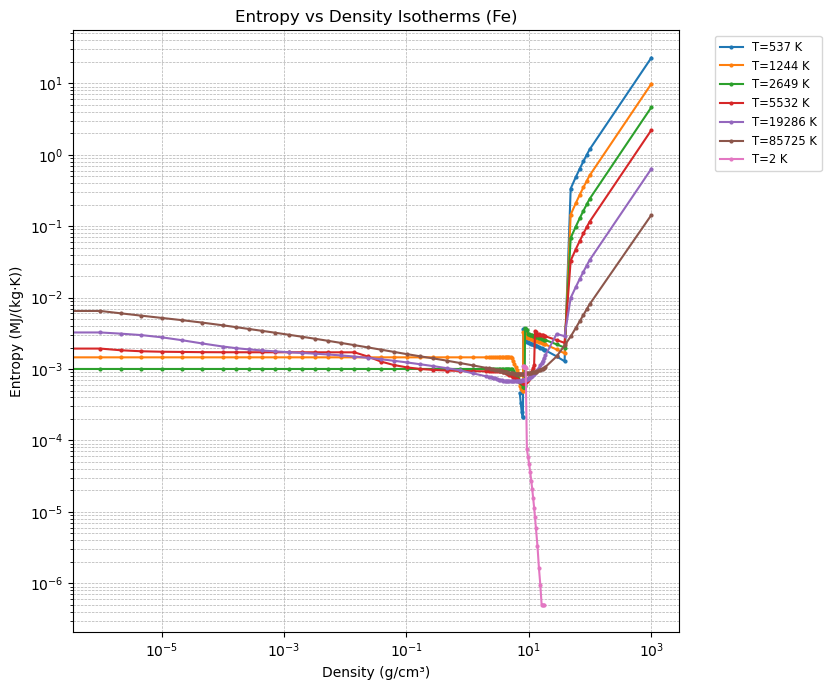

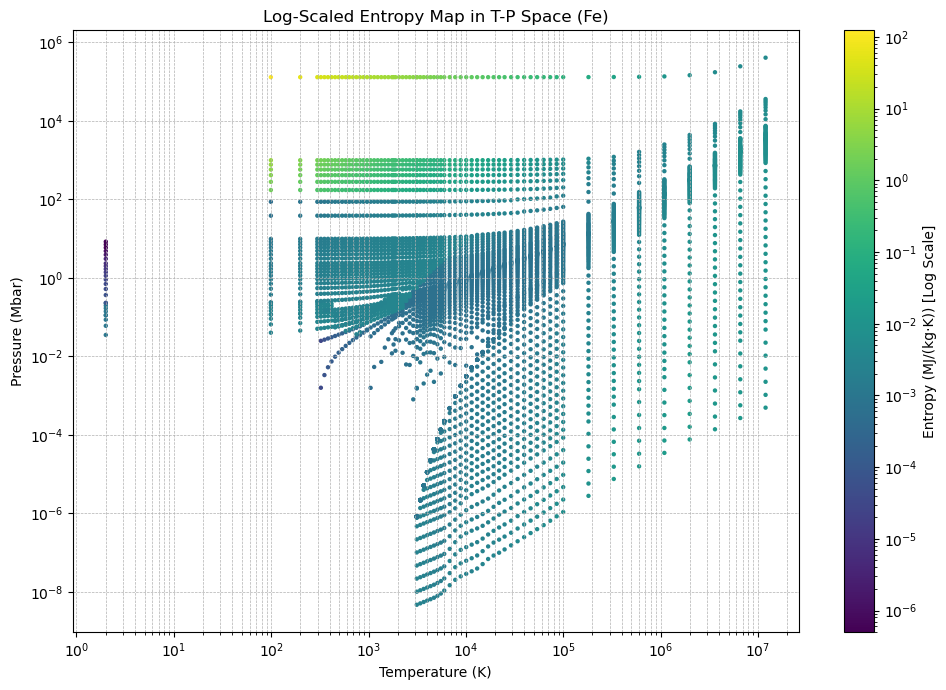

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define the filename
filename = "nouvelle_sesame_fe.dat"

# Define original column names from the file header
column_names = ['Temperature_eV', 'Density_g_cm3', 'Pressure_Mbar', 'Energy_MJ_kg', 'FreeEnergy_MJ_kg']

# Conversion factor: 1 electron-volt (eV) is approximately 11604.525 Kelvin (K)
EV_TO_K = 11604.525

# --- Load the data ---
try:
    df_eos = pd.read_csv(filename, sep='\s+', comment='#', names=column_names)

    if len(df_eos.columns) != len(column_names):
         print(f"[ERROR] Inferred {len(df_eos.columns)} columns, expected {len(column_names)}.")
         exit()
    print(f"Successfully read {len(df_eos)} rows from {filename}.")

    # --- Clean up SESAME Sentinel/Null Values ---
    df_eos.replace(-0.99999996e+25, np.nan, inplace=True)
    
    # --- Convert columns to numeric ---
    for col in column_names:
        df_eos[col] = pd.to_numeric(df_eos[col], errors='coerce')

    # --- Derived Variables ---
    df_eos['Temperature_K'] = df_eos['Temperature_eV'] * EV_TO_K

    # Calculate Entropy: S = (E - F) / T
    df_eos['Entropy_MJ_kg_K'] = np.where(
        df_eos['Temperature_K'] > 0,
        (df_eos['Energy_MJ_kg'] - df_eos['FreeEnergy_MJ_kg']) / df_eos['Temperature_K'],
        np.nan
    )

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
    exit()
except Exception as e:
    print(f"An error occurred during loading/conversion: {e}")
    exit()


# --- Updated Plotting Functions ---

def plot_pressure_density_isotherms(df, num_isotherms=8):
    plt.figure(figsize=(10, 7))
    unique_temps = df['Temperature_K'].dropna().unique()
    temps_to_plot = unique_temps[np.linspace(0, len(unique_temps) - 1, min(num_isotherms, len(unique_temps)), dtype=int)]
        
    plotted_count = 0
    for temp in temps_to_plot:
        isotherm_data = df[df['Temperature_K'] == temp].dropna(subset=['Density_g_cm3', 'Pressure_Mbar'])
        isotherm_data = isotherm_data[isotherm_data['Pressure_Mbar'] > 0]
        
        if not isotherm_data.empty:
            plt.plot(isotherm_data['Density_g_cm3'], isotherm_data['Pressure_Mbar'],
                     marker='.', markersize=4, linestyle='-', label=f'T={temp:.0f} K')
            plotted_count += 1
            
    if plotted_count > 0:
        plt.xlabel("Density (g/cm³)") 
        plt.ylabel("Pressure (Mbar)")   
        plt.xscale('log')
        plt.yscale('log')
        plt.title("Pressure vs Density Isotherms (Fe)")
        plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

def plot_entropy_density_isotherms(df, num_isotherms=8):
    """Plots Entropy vs Density for a selection of isotherms with a log-scaled Y axis."""
    plt.figure(figsize=(10, 7))
    unique_temps = df['Temperature_K'].dropna().unique()
    temps_to_plot = unique_temps[np.linspace(0, len(unique_temps) - 1, min(num_isotherms, len(unique_temps)), dtype=int)]
        
    plotted_count = 0
    for temp in temps_to_plot:
        # Filter for strictly positive entropy to allow log scaling
        isotherm_data = df[(df['Temperature_K'] == temp) & (df['Entropy_MJ_kg_K'] > 0)].dropna(subset=['Density_g_cm3'])
        
        if not isotherm_data.empty:
            plt.plot(isotherm_data['Density_g_cm3'], isotherm_data['Entropy_MJ_kg_K'],
                     marker='.', markersize=4, linestyle='-', label=f'T={temp:.0f} K')
            plotted_count += 1
            
    if plotted_count > 0:
        plt.xlabel("Density (g/cm³)")       
        plt.ylabel("Entropy (MJ/(kg·K))") 
        plt.xscale('log')
        plt.yscale('log') # Log scale applied to Entropy
        plt.title("Entropy vs Density Isotherms (Fe)")
        plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else:
        print("No valid positive entropy data to plot for 1D isotherms.")

def plot_entropy_in_TP_space(df, logscale_axes=True, logscale_entropy=True):
    """Plots Entropy as a colormap in Temperature vs Pressure space."""
    # Filter out NaNs
    df_clean = df.dropna(subset=['Temperature_K', 'Pressure_Mbar', 'Entropy_MJ_kg_K'])
    
    # Filter for strictly positive T and P if using logscale axes
    if logscale_axes:
        df_clean = df_clean[(df_clean['Temperature_K'] > 0) & (df_clean['Pressure_Mbar'] > 0)]
        
    # Filter for strictly positive Entropy if using logscale color map
    if logscale_entropy:
        df_clean = df_clean[df_clean['Entropy_MJ_kg_K'] > 0]

    if df_clean.empty:
        print("No valid data for T-P space Entropy plot after filtering.")
        return

    T = df_clean['Temperature_K'].values
    P = df_clean['Pressure_Mbar'].values
    S = df_clean['Entropy_MJ_kg_K'].values

    plt.figure(figsize=(10, 7))
    
    # Apply LogNorm to the colormap if requested
    if logscale_entropy:
        norm = mcolors.LogNorm(vmin=S.min(), vmax=S.max())
    else:
        norm = None

    scatter = plt.scatter(T, P, c=S, cmap='viridis', s=10, edgecolor='none', norm=norm)

    plt.xlabel("Temperature (K)")
    plt.ylabel("Pressure (Mbar)")
    if logscale_axes:
        plt.xscale('log')
        plt.yscale('log')
    plt.title("Log-Scaled Entropy Map in T-P Space (Fe)")

    cbar = plt.colorbar(scatter)
    label = "Entropy (MJ/(kg·K)) [Log Scale]" if logscale_entropy else "Entropy (MJ/(kg·K))"
    cbar.set_label(label)

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# --- Generate Plots ---
if not df_eos.isnull().all().all() and not df_eos.empty:
    print("\nGenerating Plots...")
    plot_pressure_density_isotherms(df_eos, num_isotherms=8)
    plot_entropy_density_isotherms(df_eos, num_isotherms=8)
    plot_entropy_in_TP_space(df_eos, logscale_axes=True, logscale_entropy=True)
else:
    print("\nSkipping plots because DataFrame is empty or all NaN.")